# Phase 2: Pre‑training the Single‑Drug Encoder

This notebook trains several GNN models to predict single-drug toxicity (pLD50) from molecular graphs.
The goal is to identify the best molecular encoder before moving to Phase 3.

Main steps:
1. Load the graph dataset prepared earlier
2. Split into train, validation, and test sets
3. Train multiple candidate GNN models
4. Compare them using validation MAE in original pLD50 units
5. Select the best model and save its encoder for later phases

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install rdkit
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cu118.html

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 23.3 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.6 MB/s eta 0:00:00
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp312-cp312-linux_x86_64.whl size=677289 sha256=e494496228ab38162f203b212322e2d690420b7a36e8543732197078a01ba6c8
  Stored in directory: /root/.cache/pip/wheels/84/20/50/44800723f57cd798630e77b3ec83bc80bd26a1e3dc3a672ef5
  Create

In [ ]:
import os
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GCNConv, GINConv, GATv2Conv,
    global_mean_pool, global_add_pool,
    BatchNorm
)

## Reproducibility

Fixing random seeds makes the split and training more stable and easier to reproduce.



In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## Load the preprocessed graph dataset

The graphs were already built from SMILES, and targets were already standardized. This avoids repeating preprocessing and keeps the training pipeline consistent.

In [ ]:
base_path = '/content/drive/MyDrive/FYP/IRP/Data'
processed_dir = os.path.join(base_path, 'processed_graphs')

graph_scaled_path = os.path.join(processed_dir, 'unified_single_drug_scaled.pt')

# Prefer the newer scaler name if it exists
single_scaler_path = os.path.join(processed_dir, 'single_pld50_scaler.pkl')
legacy_scaler_path = os.path.join(processed_dir, 'pld50_scaler.pkl')

if os.path.exists(single_scaler_path):
    scaler_path = single_scaler_path
else:
    scaler_path = legacy_scaler_path

graph_data = torch.load(graph_scaled_path, weights_only=False)
scaler = joblib.load(scaler_path)

print(f"Loaded {len(graph_data)} graphs.")
print(f"Example scaled target: {graph_data[0].y.item():.4f}")
print(f"Original pLD50 mean: {scaler.mean_[0]:.4f}")
print(f"Original pLD50 std:  {scaler.scale_[0]:.4f}")

Loaded 13579 graphs.
Example scaled target: 0.5218
Original pLD50 mean: 2.5061
Original pLD50 std:  0.9014


## Train/validation/test split

The model is trained on one subset, tuned on another, and evaluated only once on the unseen test set. This gives a fair estimate of generalization.

In [ ]:
train_val_graphs, test_graphs = train_test_split(
    graph_data, test_size=0.10, random_state=42
)

train_graphs, val_graphs = train_test_split(
    train_val_graphs, test_size=0.15, random_state=42
)

print(f"Training graphs:   {len(train_graphs)}")
print(f"Validation graphs: {len(val_graphs)}")
print(f"Test graphs:       {len(test_graphs)}")

Training graphs:   10387
Validation graphs: 1834
Test graphs:       1358


## DataLoaders

DataLoaders batch graphs efficiently and allow PyTorch Geometric to handle variable graph sizes correctly.

In [ ]:
batch_size = 64

train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

node_feat_dim = graph_data[0].x.shape[1]
print("Node feature dimension:", node_feat_dim)

Node feature dimension: 24


## Define candidate encoder models

Instead of relying on only one architecture, several strong GNN variants are compared. This helps choose the most suitable encoder for your toxicity data.

Why these models were selected

- GCN is a simple and efficient baseline. It is good for smooth neighborhood aggregation.

- GIN is often strong for molecular property prediction because it is more expressive in distinguishing local graph structures.

- GATv2 adds attention, allowing the model to weight more important neighboring atoms differently.

In [ ]:
class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2  # mean + sum pooling concatenated

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        x = torch.cat([mean_pool, sum_pool], dim=1)
        return x


class GINEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, dropout=0.2):
        super().__init__()

        mlp1 = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        mlp3 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.conv1 = GINConv(mlp1)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GINConv(mlp2)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GINConv(mlp3)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2  # mean + sum pooling concatenated

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        x = torch.cat([mean_pool, sum_pool], dim=1)
        return x


class GATv2Encoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, heads=4, dropout=0.2):
        super().__init__()
        self.conv1 = GATv2Conv(in_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, concat=True, dropout=dropout)
        self.bn3 = BatchNorm(hidden_dim)
        self.dropout = dropout
        self.out_dim = hidden_dim * 2  # mean + sum pooling concatenated

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)

        mean_pool = global_mean_pool(x, batch)
        sum_pool = global_add_pool(x, batch)
        x = torch.cat([mean_pool, sum_pool], dim=1)
        return x


class SingleDrugRegressor(nn.Module):
    def __init__(self, encoder, head_dim=64, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        self.regressor = nn.Sequential(
            nn.Linear(self.encoder.out_dim, head_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_dim, 1)
        )

    def forward(self, data):
        z = self.encoder(data.x, data.edge_index, data.batch)
        out = self.regressor(z)
        return out.view(-1)

GIN used sum pooling because it is more consistent with the original design of GIN and often preserves graph structure information more strongly than mean pooling.

## Helper functions for training and evaluation

These functions keep the code cleaner and ensure every candidate model is trained and evaluated in the same way.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


In [ ]:
def inverse_transform_targets(arr_1d, scaler):
    return scaler.inverse_transform(np.array(arr_1d).reshape(-1, 1)).flatten()


def evaluate_regression_metrics(model, loader, scaler, device):
    model.eval()
    preds_scaled = []
    trues_scaled = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            preds_scaled.extend(out.cpu().numpy())
            trues_scaled.extend(data.y.view(-1).cpu().numpy())

    preds_scaled = np.array(preds_scaled)
    trues_scaled = np.array(trues_scaled)

    preds_original = inverse_transform_targets(preds_scaled, scaler)
    trues_original = inverse_transform_targets(trues_scaled, scaler)

    mae = mean_absolute_error(trues_original, preds_original)
    rmse = np.sqrt(mean_squared_error(trues_original, preds_original))
    r2 = r2_score(trues_original, preds_original)

    return {
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "preds_original": preds_original,
        "trues_original": trues_original
    }


def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip=2.0):
    model.train()
    total_loss = 0.0

    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()

        out = model(data)
        loss = criterion(out, data.y.view(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += loss.item() * data.num_graphs

    return total_loss / len(loader.dataset)


def eval_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            loss = criterion(out, data.y.view(-1))
            total_loss += loss.item() * data.num_graphs

    return total_loss / len(loader.dataset)

## Model training routine

Each candidate model is trained with the same optimization setup, then selected using validation MAE in the original toxicity scale. This makes model comparison fair and practical.

In [ ]:
def build_model(model_name, in_dim, hidden_dim=128, dropout=0.2):
    if model_name == "GCN":
        encoder = GCNEncoder(in_dim=in_dim, hidden_dim=hidden_dim, dropout=dropout)
    elif model_name == "GIN":
        encoder = GINEncoder(in_dim=in_dim, hidden_dim=hidden_dim, dropout=dropout)
    elif model_name == "GATv2":
        encoder = GATv2Encoder(in_dim=in_dim, hidden_dim=hidden_dim, dropout=dropout)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return SingleDrugRegressor(
        encoder=encoder,
        head_dim=64,
        dropout=dropout
    )

In [ ]:
def train_candidate_model(model_name, train_loader, val_loader, scaler, device,
                          in_dim, hidden_dim=128, dropout=0.2,
                          lr=1e-3, weight_decay=1e-5,
                          max_epochs=200, patience=20):

    model = build_model(model_name, in_dim=in_dim, hidden_dim=hidden_dim, dropout=dropout).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    criterion = nn.SmoothL1Loss()

    history = []
    best_val_mae = float('inf')
    best_epoch = -1
    best_state = None
    wait = 0

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = eval_loss(model, val_loader, criterion, device)
        val_metrics = evaluate_regression_metrics(model, val_loader, scaler, device)

        scheduler.step(val_loss)

        row = {
            "epoch": epoch,
            "train_loss_scaled": train_loss,
            "val_loss_scaled": val_loss,
            "val_mae_original": val_metrics["mae"],
            "val_rmse_original": val_metrics["rmse"],
            "val_r2_original": val_metrics["r2"],
            "lr": optimizer.param_groups[0]["lr"]
        }
        history.append(row)

        # Early stopping based on best validation MAE
        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_epoch = epoch
            best_state = {
                "model_name": model_name,
                "model_state_dict": model.state_dict(),
                "hidden_dim": hidden_dim,
                "dropout": dropout,
                "node_feat_dim": in_dim,
                "best_epoch": best_epoch,
                "best_val_mae": best_val_mae
            }
            wait = 0
            print(f"[{model_name}] Epoch {epoch:03d}: new best Val MAE = {best_val_mae:.4f}")
        else:
            wait += 1

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"[{model_name}] Epoch {epoch:03d} | "
                f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                f"Val MAE: {val_metrics['mae']:.4f} | Val RMSE: {val_metrics['rmse']:.4f} | "
                f"Val R²: {val_metrics['r2']:.4f} | Wait: {wait}/{patience}"
            )

        if wait >= patience:
            print(f"[{model_name}] Early stopping at epoch {epoch:03d}. Best epoch was {best_epoch:03d} with Val MAE = {best_val_mae:.4f}")
            break

    history_df = pd.DataFrame(history)
    return best_state, history_df

## Train and compare candidate models

This is the core model selection stage. The best architecture is the one that gives the lowest validation MAE in original pLD50 units.

In [ ]:
candidate_models = ["GCN", "GIN", "GATv2"]

all_results = []
all_histories = {}
best_overall = None
best_overall_mae = float('inf')
best_model_name = None

In [ ]:
for model_name in candidate_models:
    print(f"\n========== Training {model_name} ==========")

    best_state, history_df = train_candidate_model(
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        scaler=scaler,
        device=device,
        in_dim=node_feat_dim,
        hidden_dim=128,
        dropout=0.2,
        lr=1e-3,
        weight_decay=1e-5,
        max_epochs=200,
        patience=20
    )

    all_histories[model_name] = history_df

    best_row = history_df.loc[history_df["val_mae_original"].idxmin()].to_dict()
    best_row["model_name"] = model_name
    all_results.append(best_row)

    if best_row["val_mae_original"] < best_overall_mae:
        best_overall_mae = best_row["val_mae_original"]
        best_overall = best_state
        best_model_name = model_name


========== Training GCN ==========
[GCN] Epoch 001: new best Val MAE = 0.5814
[GCN] Epoch 001 | Train Loss: 0.3603 | Val Loss: 0.3150 | Val MAE: 0.5814 | Val RMSE: 0.7936 | Val R²: 0.2450 | Wait: 0/20
[GCN] Epoch 002: new best Val MAE = 0.5418
[GCN] Epoch 004: new best Val MAE = 0.5299
[GCN] Epoch 005: new best Val MAE = 0.5134
[GCN] Epoch 006: new best Val MAE = 0.5131
[GCN] Epoch 009: new best Val MAE = 0.5117
[GCN] Epoch 010: new best Val MAE = 0.5034
[GCN] Epoch 010 | Train Loss: 0.2582 | Val Loss: 0.2549 | Val MAE: 0.5034 | Val RMSE: 0.7093 | Val R²: 0.3969 | Wait: 0/20
[GCN] Epoch 011: new best Val MAE = 0.4901
[GCN] Epoch 014: new best Val MAE = 0.4794
[GCN] Epoch 020 | Train Loss: 0.2391 | Val Loss: 0.2371 | Val MAE: 0.4900 | Val RMSE: 0.6707 | Val R²: 0.4608 | Wait: 6/20
[GCN] Epoch 021: new best Val MAE = 0.4764
[GCN] Epoch 022: new best Val MAE = 0.4650
[GCN] Epoch 026: new best Val MAE = 0.4641
[GCN] Epoch 027: new best Val MAE = 0.4530
[GCN] Epoch 029: new best Val MAE = 

In [ ]:
results_df = pd.DataFrame(all_results).sort_values("val_mae_original").reset_index(drop=True)
results_df

,epoch,train_loss_scaled,val_loss_scaled,val_mae_original,val_rmse_original,val_r2_original,lr,model_name
0,104.0,0.152414,0.175333,0.405362,0.573964,0.605047,0.000031,GIN
1,78.0,0.189980,0.190722,0.426078,0.594291,0.576577,0.000063,GCN
2,64.0,0.198373,0.194689,0.435554,0.597258,0.572339,0.000250,GATv2


## Brief interpretation of model selection

The winning model is the one with the lowest validation MAE in original pLD50 units, which means it predicts toxicity values more accurately on unseen validation molecules.

In [ ]:
print(f"Best model selected for Phase 3: {best_model_name}")
print(results_df[["model_name", "val_mae_original", "val_rmse_original", "val_r2_original"]])

Best model selected for Phase 3: GIN
  model_name  val_mae_original  val_rmse_original  val_r2_original
0        GIN          0.405362           0.573964         0.605047
1        GCN          0.426078           0.594291         0.576577
2      GATv2          0.435554           0.597258         0.572339


## Save comparison results

In [ ]:
results_csv_path = os.path.join(processed_dir, "phase2_model_comparison.csv")
results_df.to_csv(results_csv_path, index=False)
print("Saved comparison table to:", results_csv_path)

Saved comparison table to: /content/drive/MyDrive/FYP/IRP/Data/processed_graphs/phase2_model_comparison.csv


## Load the best model and evaluate on test set

The test set is only used after model selection. This gives the final unbiased performance estimate.

In [ ]:
best_model = build_model(
    model_name=best_overall["model_name"],
    in_dim=best_overall["node_feat_dim"],
    hidden_dim=best_overall["hidden_dim"],
    dropout=best_overall["dropout"]
).to(device)

best_model.load_state_dict(best_overall["model_state_dict"])

<All keys matched successfully>

In [ ]:
test_metrics = evaluate_regression_metrics(best_model, test_loader, scaler, device)

print(f"Best model: {best_model_name}")
print(f"Test MAE  (original pLD50): {test_metrics['mae']:.4f}")
print(f"Test RMSE (original pLD50): {test_metrics['rmse']:.4f}")
print(f"Test R²   (original pLD50): {test_metrics['r2']:.4f}")

Best model: GIN
Test MAE  (original pLD50): 0.4028
Test RMSE (original pLD50): 0.5620
Test R²   (original pLD50): 0.5991


## Save the best full model

In [ ]:
best_model_path = os.path.join(processed_dir, "best_single_drug_model.pt")
torch.save(best_overall, best_model_path)
print("Saved best full model to:", best_model_path)

Saved best full model to: /content/drive/MyDrive/FYP/IRP/Data/processed_graphs/best_single_drug_model.pt


## Save the pretrained encoder only

Phase 3 and Phase 4 only need the molecular encoder, not the regression head. Saving only the encoder keeps transfer learning simpler.

In [ ]:
encoder_state = {
    "model_name": best_model_name,
    "hidden_dim": best_overall["hidden_dim"],
    "dropout": best_overall["dropout"],
    "node_feat_dim": best_overall["node_feat_dim"],
    "encoder_state_dict": best_model.encoder.state_dict()
}

pretrained_encoder_path = os.path.join(processed_dir, "pretrained_encoder.pt")
torch.save(encoder_state, pretrained_encoder_path)
print("Saved pretrained encoder to:", pretrained_encoder_path)

Saved pretrained encoder to: /content/drive/MyDrive/FYP/IRP/Data/processed_graphs/pretrained_encoder.pt


## Residual analysis

Residual plots help check whether the model makes systematic errors across the toxicity range.

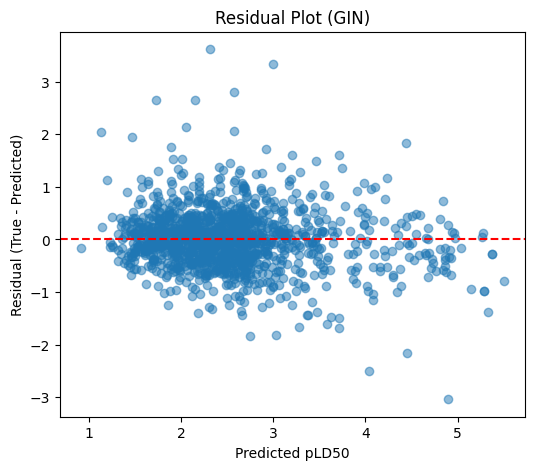

In [ ]:
preds_original = test_metrics["preds_original"]
trues_original = test_metrics["trues_original"]
residuals = trues_original - preds_original

plt.figure(figsize=(6, 5))
plt.scatter(preds_original, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted pLD50")
plt.ylabel("Residual (True - Predicted)")
plt.title(f"Residual Plot ({best_model_name})")
plt.show()

## Plot learning curves for all candidate models

Learning curves help compare training stability and overfitting behavior.

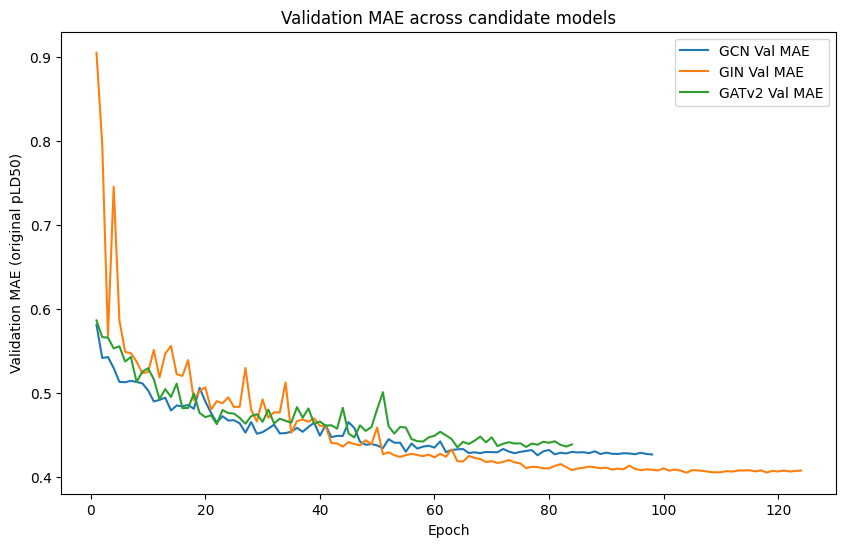

In [ ]:
plt.figure(figsize=(10, 6))

for model_name, hist_df in all_histories.items():
    plt.plot(hist_df["epoch"], hist_df["val_mae_original"], label=f"{model_name} Val MAE")

plt.xlabel("Epoch")
plt.ylabel("Validation MAE (original pLD50)")
plt.title("Validation MAE across candidate models")
plt.legend()
plt.show()

## Model Comparison Results

Three candidate graph neural network architectures were evaluated for single-drug toxicity prediction: **GIN**, **GCN**, and **GATv2**. Performance was compared using validation metrics in the original pLD₅₀ scale.

| Rank | Model | Validation MAE | Validation RMSE | Validation R² |
|------|-------|----------------|-----------------|---------------|
| 1 | GIN | 0.4054 | 0.5740 | 0.6050 |
| 2 | GCN | 0.4261 | 0.5943 | 0.5766 |
| 3 | GATv2 | 0.4356 | 0.5973 | 0.5723 |

### Selected Model

The **GIN model** achieved the best overall validation performance, with the **lowest MAE (0.4054)** and **RMSE (0.5740)**, and the **highest R² (0.6050)** among all evaluated models. Therefore, GIN was selected as the final single-drug encoder for subsequent phases.

### Why GIN Was Selected

GIN was chosen because it provided the most accurate toxicity predictions on unseen validation molecules. This result is consistent with the known strength of GIN in molecular learning tasks. Compared with standard graph convolution, GIN is more expressive in distinguishing subtle structural differences between molecular graphs. This is especially important for toxicity prediction, where small changes in chemical structure can lead to large differences in biological effect. Since GIN achieved the best validation performance while preserving a relatively simple architecture, it was selected as the pretrained encoder for Phase 3 and Phase 4.